In [ ]:
import numpy as np
import pandas as pd

def generate_pq_data(n_samples=1000, fs=3200, T=10/60):
    """
    Generates a dataset of synthetic Power Quality signals.
    Classes: 0=Normal, 1=Sag, 2=Swell
    """
    t = np.linspace(0, T, int(T*fs)) # Time vector (10 cycles)
    data = []
    labels = []

    for _ in range(n_samples):
        # Base parameters
        freq = 60
        omega = 2 * np.pi * freq

        # Randomly choose a class
        event_type = np.random.choice(['Normal', 'Sag', 'Swell'])

        # Base Signal
        sig = np.sin(omega * t)

        # Apply Disturbance
        if event_type == 'Normal':
            label = 0
            # Just add random Gaussian noise
            noise = np.random.normal(0, 0.01, len(t))
            final_sig = sig + noise

        elif event_type == 'Sag':
            label = 1
            # Drop amplitude to 0.1 - 0.9 randomly
            mag = np.random.uniform(0.1, 0.9)
            start = np.random.randint(len(t)//4, len(t)//2)
            end = np.random.randint(start + 100, 3*len(t)//4)
            sig[start:end] *= mag
            noise = np.random.normal(0, 0.01, len(t))
            final_sig = sig + noise

        elif event_type == 'Swell':
            label = 2
            # Increase amplitude to 1.1 - 1.8 randomly
            mag = np.random.uniform(1.1, 1.8)
            start = np.random.randint(len(t)//4, len(t)//2)
            end = np.random.randint(start + 100, 3*len(t)//4)
            sig[start:end] *= mag
            noise = np.random.normal(0, 0.01, len(t))
            final_sig = sig + noise

        data.append(final_sig)
        labels.append(label)

    return np.array(data), np.array(labels)

# Generate and Save
X, y = generate_pq_data(n_samples=1000)
print(f"Generated Dataset: X shape={X.shape}, y shape={y.shape}")

#Save to CSV (optional)
pd.DataFrame(X).to_csv("pq_dataset_X.csv", index=False)
pd.DataFrame(y).to_csv("pq_dataset_y.csv", index=False)

Generated Dataset: X shape=(1000, 533), y shape=(1000,)


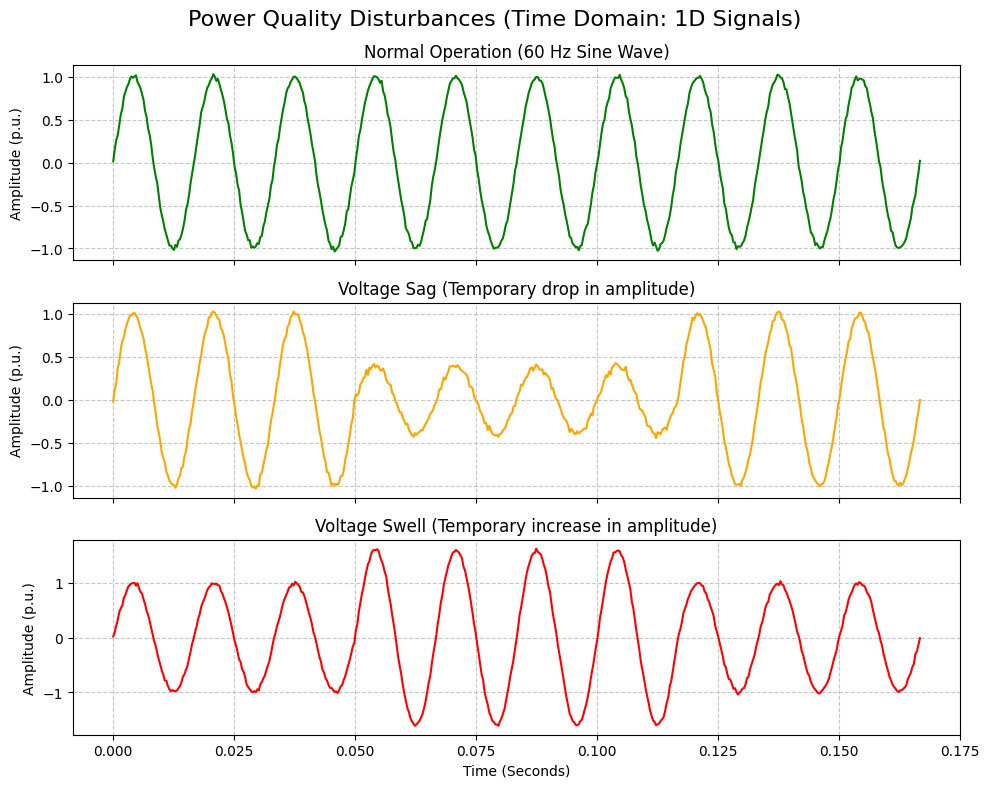

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def generate_sample_signals(fs=3200, T=10/60):
    """Generates one Normal, one Sag, and one Swell signal for visualization."""
    t = np.linspace(0, T, int(T*fs)) # Time vector for 10 cycles (60Hz)
    omega = 2 * np.pi * 60

    # 1. Normal Signal (Just noise)
    sig_normal = np.sin(omega * t) + np.random.normal(0, 0.02, len(t))

    # 2. Voltage Sag (Drop to 40% amplitude in the middle)
    sig_sag = np.sin(omega * t)
    start_idx, end_idx = int(len(t)*0.3), int(len(t)*0.7)
    sig_sag[start_idx:end_idx] *= 0.4
    sig_sag += np.random.normal(0, 0.02, len(t))

    # 3. Voltage Swell (Spike to 160% amplitude in the middle)
    sig_swell = np.sin(omega * t)
    sig_swell[start_idx:end_idx] *= 1.6
    sig_swell += np.random.normal(0, 0.02, len(t))

    return t, sig_normal, sig_sag, sig_swell

# Generate the data
t, normal, sag, swell = generate_sample_signals()

# Plotting
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
fig.suptitle('Power Quality Disturbances (Time Domain: 1D Signals)', fontsize=16)

# Plot Normal
axes[0].plot(t, normal, color='green')
axes[0].set_title('Normal Operation (60 Hz Sine Wave)')
axes[0].set_ylabel('Amplitude (p.u.)')
axes[0].grid(True, linestyle='--', alpha=0.7)

# Plot Sag
axes[1].plot(t, sag, color='orange')
axes[1].set_title('Voltage Sag (Temporary drop in amplitude)')
axes[1].set_ylabel('Amplitude (p.u.)')
axes[1].grid(True, linestyle='--', alpha=0.7)

# Plot Swell
axes[2].plot(t, swell, color='red')
axes[2].set_title('Voltage Swell (Temporary increase in amplitude)')
axes[2].set_xlabel('Time (Seconds)')
axes[2].set_ylabel('Amplitude (p.u.)')
axes[2].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Turning 1D series into 2D Spectograms


In [ ]:
pip install numpy matplotlib PyWavelets

In [ ]:
import os
import numpy as np
import pywt
import matplotlib.pyplot as plt

# 1. Signal Generation Function (from our previous step)
def generate_pq_data(n_samples=6000, fs=3200, T=10/60):
    """
    Generates synthetic 1D Power Quality signals.
    Generates an equal amount of Normal, Sag, and Swell signals.
    """
    t = np.linspace(0, T, int(T*fs), endpoint=False)
    data = []
    labels = []

    # Generate 200 of each class to get 600 total samples
    samples_per_class = n_samples // 3

    for class_label, event_type in enumerate(['Normal', 'Sag', 'Swell']):
        for _ in range(samples_per_class):
            omega = 2 * np.pi * 60
            sig = np.sin(omega * t)

            if event_type == 'Normal':
                final_sig = sig + np.random.normal(0, 0.02, len(t))

            elif event_type == 'Sag':
                mag = np.random.uniform(0.1, 0.9)
                start = np.random.randint(len(t)//4, len(t)//2)
                end = np.random.randint(start + 100, 3*len(t)//4)
                sig[start:end] *= mag
                final_sig = sig + np.random.normal(0, 0.02, len(t))

            elif event_type == 'Swell':
                mag = np.random.uniform(1.1, 1.8)
                start = np.random.randint(len(t)//4, len(t)//2)
                end = np.random.randint(start + 100, 3*len(t)//4)
                sig[start:end] *= mag
                final_sig = sig + np.random.normal(0, 0.02, len(t))

            data.append(final_sig)
            labels.append(class_label)

    return np.array(data), np.array(labels)

# 2. CWT Transformation and Image Saving Function
def create_image_dataset(X, y, base_dir="pq_image_dataset"):
    """
    Applies CWT to 1D signals and saves them as 2D images in categorized folders.
    """
    classes = {0: "Normal", 1: "Sag", 2: "Swell"}

    # Create the directory structure (e.g., dataset/Normal/, dataset/Sag/)
    for cls_name in classes.values():
        os.makedirs(os.path.join(base_dir, cls_name), exist_ok=True)

    print(f"Saving images to: {os.path.abspath(base_dir)}")

    # Continuous Wavelet Transform Parameters
    scales = np.arange(1, 128)
    wavelet = 'cmor'  # Complex Morlet wavelet

    # Process each signal
    for i in range(len(X)):
        signal = X[i]
        label = y[i]
        class_name = classes[label]

        # Apply CWT
        # We only need the coefficients, not the frequencies
        coeffs, _ = pywt.cwt(signal, scales, wavelet)

        # Calculate the power (magnitude squared) to form the image pixels
        power = np.abs(coeffs)**2

        # Define the file path
        filename = os.path.join(base_dir, class_name, f"{class_name}_{i:04d}.png")

        # Save the 2D array directly as an image.
        # cmap='jet' gives it the classic thermal/spectrogram color mapping.
        # origin='lower' ensures the low frequencies (scale 1) are at the bottom.
        plt.imsave(filename, power, cmap='jet', origin='lower')

        # Print progress
        if (i + 1) % 100 == 0:
            print(f"Processed {i + 1}/{len(X)} images...")

    print("Dataset generation successfully completed!")

# 3. Execution Block
if __name__ == "__main__":
    print("1. Generating 1D synthetic signals...")
    # Generating 600 total signals (200 per class) to keep the initial run fast.
    # For Phase 4 of your proposal, you can increase this to 3000 or more.
    X_data, y_labels = generate_pq_data(n_samples=6000)

    print("2. Transforming to 2D Spectrograms and saving to disk...")
    create_image_dataset(X_data, y_labels, base_dir="pq_spectrograms")

1. Generating 1D synthetic signals...
2. Transforming to 2D Spectrograms and saving to disk...
Saving images to: /content/pq_spectrograms


/usr/local/lib/python3.12/dist-packages/pywt/_cwt.py:113: FutureWarning: Wavelets from the family cmor, without parameters specified in the name are deprecated. The name should follow the format cmorB-C, where B and C are floats representing the bandwidth frequency and center frequency, respectively (example, for backward compatibility: cmor = cmor1.0-0.5).
  wavelet = DiscreteContinuousWavelet(wavelet)


Processed 100/6000 images...
Processed 200/6000 images...
Processed 300/6000 images...
Processed 400/6000 images...
Processed 500/6000 images...
Processed 600/6000 images...
Processed 700/6000 images...
Processed 800/6000 images...
Processed 900/6000 images...
Processed 1000/6000 images...
Processed 1100/6000 images...
Processed 1200/6000 images...
Processed 1300/6000 images...
Processed 1400/6000 images...
Processed 1500/6000 images...
Processed 1600/6000 images...
Processed 1700/6000 images...
Processed 1800/6000 images...
Processed 1900/6000 images...
Processed 2000/6000 images...
Processed 2100/6000 images...
Processed 2200/6000 images...
Processed 2300/6000 images...
Processed 2400/6000 images...
Processed 2500/6000 images...
Processed 2600/6000 images...
Processed 2700/6000 images...
Processed 2800/6000 images...
Processed 2900/6000 images...
Processed 3000/6000 images...
Processed 3100/6000 images...
Processed 3200/6000 images...
Processed 3300/6000 images...
Processed 3400/6000

Run this block to show the signal and its corresponding spectogram

Visualizing sample index 5600...


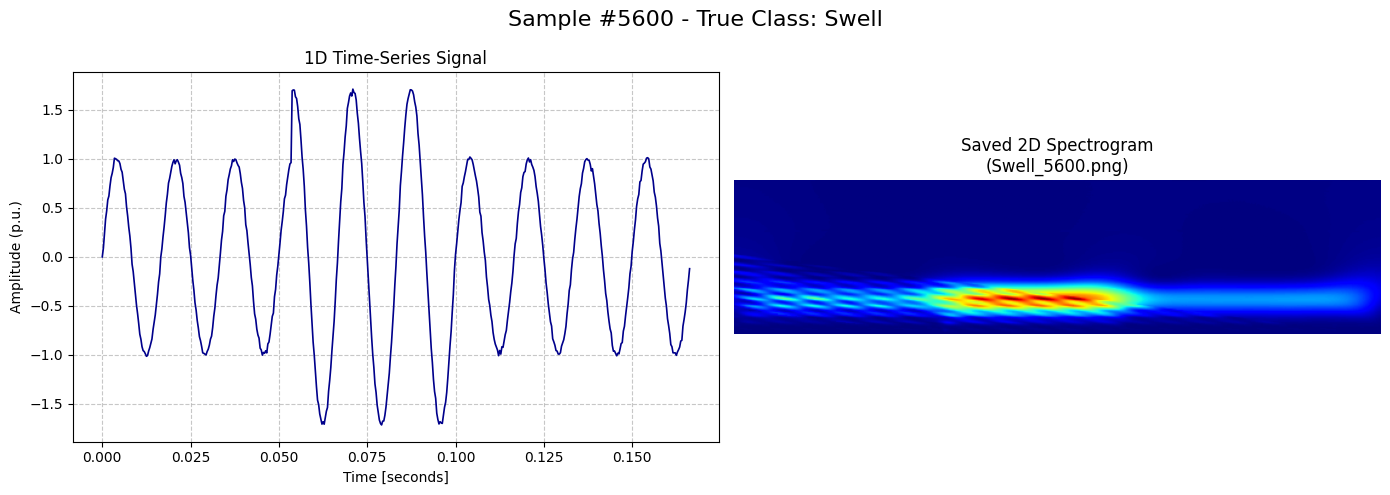

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def visualize_sample(X, y, sample_index, base_dir="pq_spectrograms", fs=3200):
    """
    Plots a 1D signal from the dataset array and loads its corresponding
    saved 2D spectrogram image from the directory.
    """
    classes = {0: "Normal", 1: "Sag", 2: "Swell"}

    # 1. Get the 1D signal and its label
    signal = X[sample_index]
    label = y[sample_index]
    class_name = classes[label]

    # Create time vector for the 1D plot
    T = len(signal) / fs
    t = np.linspace(0, T, len(signal), endpoint=False)

    # 2. Construct the file path for the saved spectrogram
    # The filename was formatted as: ClassName_000X.png
    filename = f"{class_name}_{sample_index:04d}.png"
    filepath = os.path.join(base_dir, class_name, filename)

    # Check if the image exists
    if not os.path.exists(filepath):
        print(f"Error: Could not find image at {filepath}")
        return

    # Load the saved image
    spectrogram_img = mpimg.imread(filepath)

    # 3. Plotting
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Sample #{sample_index} - True Class: {class_name}', fontsize=16)

    # Plot A: The 1D Signal
    axes[0].plot(t, signal, color='darkblue', linewidth=1.2)
    axes[0].set_title('1D Time-Series Signal')
    axes[0].set_xlabel('Time [seconds]')
    axes[0].set_ylabel('Amplitude (p.u.)')
    axes[0].grid(True, linestyle='--', alpha=0.7)

    # Plot B: The Saved 2D Spectrogram
    # We hide the axes ticks since it's an image loaded from disk
    axes[1].imshow(spectrogram_img)
    axes[1].set_title(f'Saved 2D Spectrogram\n({filename})')
    axes[1].axis('off') # Hide axes for a clean image view

    plt.tight_layout()
    plt.show()

# --- Execution ---
# Choose which sample index you want to look at (e.g., sample 42)
# (Ensure X_data and y_labels exist from the previous generation script)
sample_to_view = 5600

print(f"Visualizing sample index {sample_to_view}...")
visualize_sample(X_data, y_labels, sample_index=sample_to_view)

Loading datasets...
Found 6000 files belonging to 3 classes.
Using 4800 files for training.
Found 6000 files belonging to 3 classes.
Using 1200 files for validation.
Target Classes: ['Normal', 'Sag', 'Swell']


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,288,067 (16.36 MB)

 Trainable params: 4,288,067 (16.36 MB)

 Non-trainable params: 0 (0.00 B)


Starting training for 10 epochs...
Epoch 1/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 192s 1s/step - accuracy: 0.8758 - loss: 0.3154 - val_accuracy: 1.0000 - val_loss: 4.2681e-05
Epoch 2/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 182s 1s/step - accuracy: 1.0000 - loss: 6.3794e-05 - val_accuracy: 1.0000 - val_loss: 2.4991e-05
Epoch 3/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 181s 1s/step - accuracy: 1.0000 - loss: 2.3072e-05 - val_accuracy: 1.0000 - val_loss: 1.5027e-05
Epoch 4/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 182s 1s/step - accuracy: 1.0000 - loss: 1.1844e-05 - val_accuracy: 1.0000 - val_loss: 1.0577e-05
Epoch 5/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 180s 1s/step - accuracy: 1.0000 - loss: 1.0891e-05 - val_accuracy: 1.0000 - val_loss: 7.6050e-06
Epoch 6/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 181s 1s/step - accuracy: 1.0000 - loss: 8.2219e-06 - val_accuracy: 1.0000 - val_loss: 5.6468e-06
Epoch 7/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 181s 1s/step - accuracy: 1.0000 - loss: 5.2766e-06 - val_accuracy: 1.0000 - val_loss: 4.4945e-06
Epoch 8/1

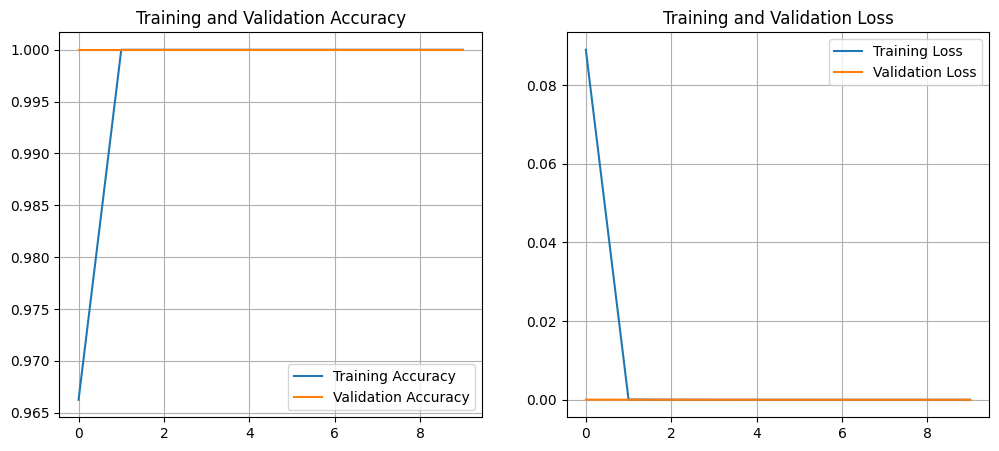

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# 1. Dataset Configuration
# We resize the spectrograms to 128x128 to balance detail and RAM efficiency.
batch_size = 32
img_height = 128
img_width = 128
data_dir = "pq_spectrograms"  # The folder generated in Phase 2

print("Loading datasets...")
# Training dataset (80% of the data)
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

# Validation dataset (20% of the data)
val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

class_names = train_ds.class_names
print(f"Target Classes: {class_names}")

# Optimize dataset loading for performance (crucial when scaling up to thousands of images)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# 2. Build the CNN Architecture
# This architecture is deep enough to catch transient visual features but
# light enough to avoid instant overfitting on our prototype dataset.
model = models.Sequential([
  # Preprocessing: Normalize pixel values from [0, 255] to [0, 1]
  layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),

  # Convolutional Block 1: Basic Edge/Line Detection
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),

  # Convolutional Block 2: Intermediate Patterns
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),

  # Convolutional Block 3: Complex Spectrogram Textures
  layers.Conv2D(128, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),

  # Regularization: Randomly drop 20% of neurons to force the network to
  # learn generalized features rather than memorizing the training noise
  layers.Dropout(0.2),

  # Classification Head
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(len(class_names)) # Output layer: 1 node per class
])

# 3. Compile the Model
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# Print a summary of the network dimensions and parameters
model.summary()

# 4. Train the Network
epochs = 10
print(f"\nStarting training for {epochs} epochs...")
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

# 5. Visualize the Training Results
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.grid(True)
plt.show()

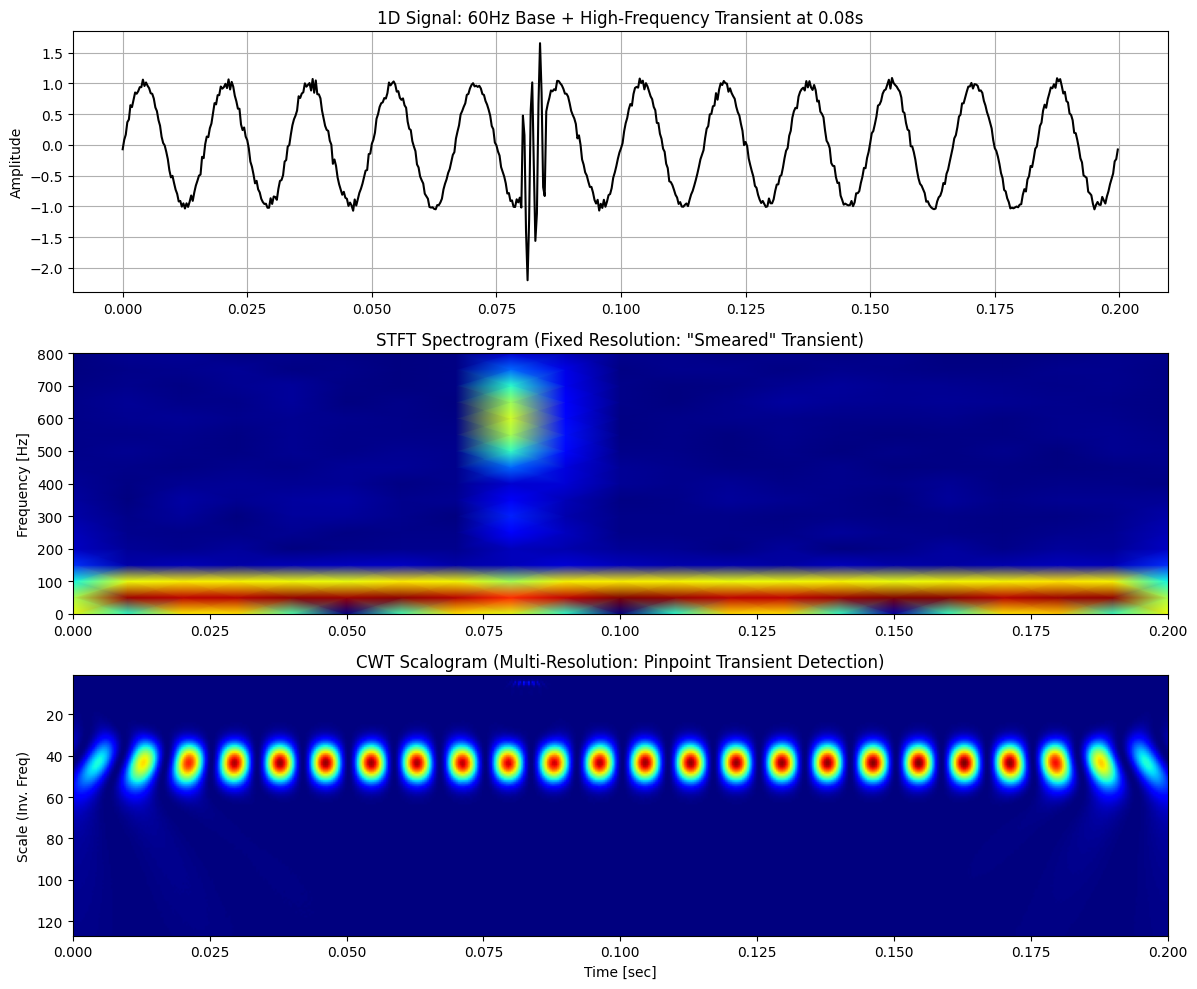

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import pywt # Import PyWavelets for CWT

# 1. Generate a Non-Stationary Signal
fs = 3200
T = 0.2
t = np.linspace(0, T, int(T*fs), endpoint=False)

# Base 60Hz grid signal
sig = np.sin(2 * np.pi * 60 * t)

# Add a high-frequency transient spike (600Hz) between 0.08s and 0.085s
start, end = int(0.08 * fs), int(0.085 * fs)
sig[start:end] += 1.5 * np.sin(2 * np.pi * 600 * t[start:end])

# Add slight noise
sig += np.random.normal(0, 0.05, len(t))

# 2. Short-Time Fourier Transform (STFT)
# We must pick a fixed window size (e.g., nperseg=64)
f_stft, t_stft, Zxx = signal.stft(sig, fs, nperseg=64)
stft_power = np.abs(Zxx)

# 3. Continuous Wavelet Transform (CWT)
# CWT automatically adapts across scales
widths = np.arange(1, 128)
# Corrected: Use pywt.cwt instead of signal.cwt
cwtmatr, _ = pywt.cwt(sig, widths, 'morl') # Using 'morl' as a common CWT wavelet
cwt_power = np.abs(cwtmatr)**2

# 4. Plotting the Comparison
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Plot A: The 1D Signal
axes[0].plot(t, sig, color='black')
axes[0].set_title('1D Signal: 60Hz Base + High-Frequency Transient at 0.08s')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True)

# Plot B: STFT Spectrogram
# Notice how the transient is "smeared" across time due to the fixed window
axes[1].pcolormesh(t_stft, f_stft, stft_power, shading='gouraud', cmap='jet')
axes[1].set_title('STFT Spectrogram (Fixed Resolution: "Smeared" Transient)')
axes[1].set_ylabel('Frequency [Hz]')
axes[1].set_ylim(0, 800)

# Plot C: CWT Scalogram
# Notice the sharp, pinpoint detection of the transient in time
extent = [0, T, widths[-1], widths[0]]
axes[2].imshow(cwt_power, extent=extent, cmap='jet', aspect='auto', origin='upper')
axes[2].set_title('CWT Scalogram (Multi-Resolution: Pinpoint Transient Detection)')
axes[2].set_ylabel('Scale (Inv. Freq)')
axes[2].set_xlabel('Time [sec]')

plt.tight_layout()
plt.show()

Next code add 6 different classes:

In [ ]:
import os
import numpy as np
import pywt
import matplotlib.pyplot as plt

def generate_complex_pq_data(n_samples_per_class=1000, fs=3200, T=10/60):
    """
    Generates a 6-class dataset of synthetic Power Quality signals.
    Classes: Normal, Sag, Swell, Harmonics, Transient, Complex
    """
    t = np.linspace(0, T, int(T*fs), endpoint=False)
    data = []
    labels = []

    classes = ['Normal', 'Sag', 'Swell', 'Harmonics', 'Transient', 'Complex']
    omega = 2 * np.pi * 60 # Fundamental frequency

    for class_label, event_type in enumerate(classes):
        for _ in range(n_samples_per_class):
            # Base 60Hz Signal
            sig = np.sin(omega * t)

            # 1. Normal
            if event_type == 'Normal':
                final_sig = sig + np.random.normal(0, 0.02, len(t))

            # 2. Sag (10% to 90% drop)
            elif event_type == 'Sag':
                mag = np.random.uniform(0.1, 0.9)
                start = np.random.randint(len(t)//4, len(t)//2)
                end = np.random.randint(start + 100, 3*len(t)//4)
                sig[start:end] *= mag
                final_sig = sig + np.random.normal(0, 0.02, len(t))

            # 3. Swell (110% to 180% spike)
            elif event_type == 'Swell':
                mag = np.random.uniform(1.1, 1.8)
                start = np.random.randint(len(t)//4, len(t)//2)
                end = np.random.randint(start + 100, 3*len(t)//4)
                sig[start:end] *= mag
                final_sig = sig + np.random.normal(0, 0.02, len(t))

            # 4. Harmonics (Adding 3rd, 5th, and 7th harmonics)
            elif event_type == 'Harmonics':
                alpha3 = np.random.uniform(0.05, 0.15)
                alpha5 = np.random.uniform(0.05, 0.10)
                alpha7 = np.random.uniform(0.01, 0.05)
                harmonic_sig = sig + (alpha3 * np.sin(3 * omega * t)) + \
                                     (alpha5 * np.sin(5 * omega * t)) + \
                                     (alpha7 * np.sin(7 * omega * t))
                final_sig = harmonic_sig + np.random.normal(0, 0.02, len(t))

            # 5. Oscillatory Transient (High frequency decaying ringing)
            elif event_type == 'Transient':
                transient_freq = np.random.uniform(500, 1500)
                tau = np.random.uniform(0.005, 0.015) # Decay rate
                start = np.random.randint(len(t)//4, 3*len(t)//4)

                # Create the decaying transient
                t_trans = t[start:] - t[start]
                transient = np.exp(-t_trans/tau) * np.sin(2 * np.pi * transient_freq * t_trans)

                final_sig = np.copy(sig)
                final_sig[start:] += transient * np.random.uniform(0.3, 0.8)
                final_sig += np.random.normal(0, 0.02, len(t))

            # 6. Complex (Sag + Harmonics)
            elif event_type == 'Complex':
                # First apply harmonics
                alpha3 = np.random.uniform(0.05, 0.15)
                alpha5 = np.random.uniform(0.05, 0.10)
                complex_sig = sig + (alpha3 * np.sin(3 * omega * t)) + (alpha5 * np.sin(5 * omega * t))

                # Then apply a Sag
                mag = np.random.uniform(0.2, 0.8)
                start = np.random.randint(len(t)//4, len(t)//2)
                end = np.random.randint(start + 100, 3*len(t)//4)
                complex_sig[start:end] *= mag

                final_sig = complex_sig + np.random.normal(0, 0.02, len(t))

            data.append(final_sig)
            labels.append(class_label)

    return np.array(data), np.array(labels)

def create_complex_image_dataset(X, y, base_dir="pq_complex_spectrograms"):
    classes = {0: "Normal", 1: "Sag", 2: "Swell", 3: "Harmonics", 4: "Transient", 5: "Complex"}

    for cls_name in classes.values():
        os.makedirs(os.path.join(base_dir, cls_name), exist_ok=True)

    print(f"Generating CWT Spectrograms in: {os.path.abspath(base_dir)}")
    scales = np.arange(1, 128)
    wavelet = 'cmor'

    for i in range(len(X)):
        signal = X[i]
        class_name = classes[y[i]]

        coeffs, _ = pywt.cwt(signal, scales, wavelet)
        power = np.abs(coeffs)**2

        filename = os.path.join(base_dir, class_name, f"{class_name}_{i:04d}.png")
        plt.imsave(filename, power, cmap='jet', origin='lower')

        if (i + 1) % 200 == 0:
            print(f"Processed {i + 1}/{len(X)} images...")

    print("Complex dataset generation successfully completed!")

# --- Execution ---
if __name__ == "__main__":
    print("1. Generating 1D complex synthetic signals (1200 total, 200 per class)...")
    X_data, y_labels = generate_complex_pq_data(n_samples_per_class=1000)

    print("2. Transforming to 2D Spectrograms and saving to disk...")
    # Saving to a new folder to avoid mixing with the old data
    create_complex_image_dataset(X_data, y_labels, base_dir="pq_complex_spectrograms")

1. Generating 1D complex synthetic signals (1200 total, 200 per class)...
2. Transforming to 2D Spectrograms and saving to disk...
Generating CWT Spectrograms in: /content/pq_complex_spectrograms


/usr/local/lib/python3.12/dist-packages/pywt/_cwt.py:113: FutureWarning: Wavelets from the family cmor, without parameters specified in the name are deprecated. The name should follow the format cmorB-C, where B and C are floats representing the bandwidth frequency and center frequency, respectively (example, for backward compatibility: cmor = cmor1.0-0.5).
  wavelet = DiscreteContinuousWavelet(wavelet)


Processed 200/6000 images...
Processed 400/6000 images...
Processed 600/6000 images...
Processed 800/6000 images...
Processed 1000/6000 images...
Processed 1200/6000 images...
Processed 1400/6000 images...
Processed 1600/6000 images...
Processed 1800/6000 images...
Processed 2000/6000 images...
Processed 2200/6000 images...
Processed 2400/6000 images...
Processed 2600/6000 images...
Processed 2800/6000 images...
Processed 3000/6000 images...
Processed 3200/6000 images...
Processed 3400/6000 images...
Processed 3600/6000 images...
Processed 3800/6000 images...
Processed 4000/6000 images...
Processed 4200/6000 images...
Processed 4400/6000 images...
Processed 4600/6000 images...
Processed 4800/6000 images...
Processed 5000/6000 images...
Processed 5200/6000 images...
Processed 5400/6000 images...
Processed 5600/6000 images...
Processed 5800/6000 images...
Processed 6000/6000 images...
Complex dataset generation successfully completed!


The extended phase 4 that includes the 6 variants of signals

Loading complex datasets...
Found 7000 files belonging to 6 classes.
Using 5600 files for training.
Found 7000 files belonging to 6 classes.
Using 1400 files for validation.
Target Classes: ['Complex', 'Harmonics', 'Normal', 'Sag', 'Swell', 'Transient']

Starting training for 12 epochs...
Epoch 1/12


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


175/175 ━━━━━━━━━━━━━━━━━━━━ 222s 1s/step - accuracy: 0.4661 - loss: 1.2197 - val_accuracy: 0.7843 - val_loss: 0.6118
Epoch 2/12
175/175 ━━━━━━━━━━━━━━━━━━━━ 212s 1s/step - accuracy: 0.7191 - loss: 0.5750 - val_accuracy: 0.7321 - val_loss: 0.4841
Epoch 3/12
175/175 ━━━━━━━━━━━━━━━━━━━━ 212s 1s/step - accuracy: 0.8132 - loss: 0.4122 - val_accuracy: 0.9093 - val_loss: 0.2020
Epoch 4/12
175/175 ━━━━━━━━━━━━━━━━━━━━ 218s 1s/step - accuracy: 0.9071 - loss: 0.1873 - val_accuracy: 0.9164 - val_loss: 0.1595
Epoch 5/12
175/175 ━━━━━━━━━━━━━━━━━━━━ 212s 1s/step - accuracy: 0.9203 - loss: 0.1557 - val_accuracy: 0.9214 - val_loss: 0.1528
Epoch 6/12
175/175 ━━━━━━━━━━━━━━━━━━━━ 210s 1s/step - accuracy: 0.9212 - loss: 0.1488 - val_accuracy: 0.9236 - val_loss: 0.1443
Epoch 7/12
175/175 ━━━━━━━━━━━━━━━━━━━━ 213s 1s/step - accuracy: 0.9266 - loss: 0.1445 - val_accuracy: 0.9200 - val_loss: 0.1537
Epoch 8/12
175/175 ━━━━━━━━━━━━━━━━━━━━ 262s 1s/step - accuracy: 0.9267 - loss: 0.1414 - val_accuracy: 0.926

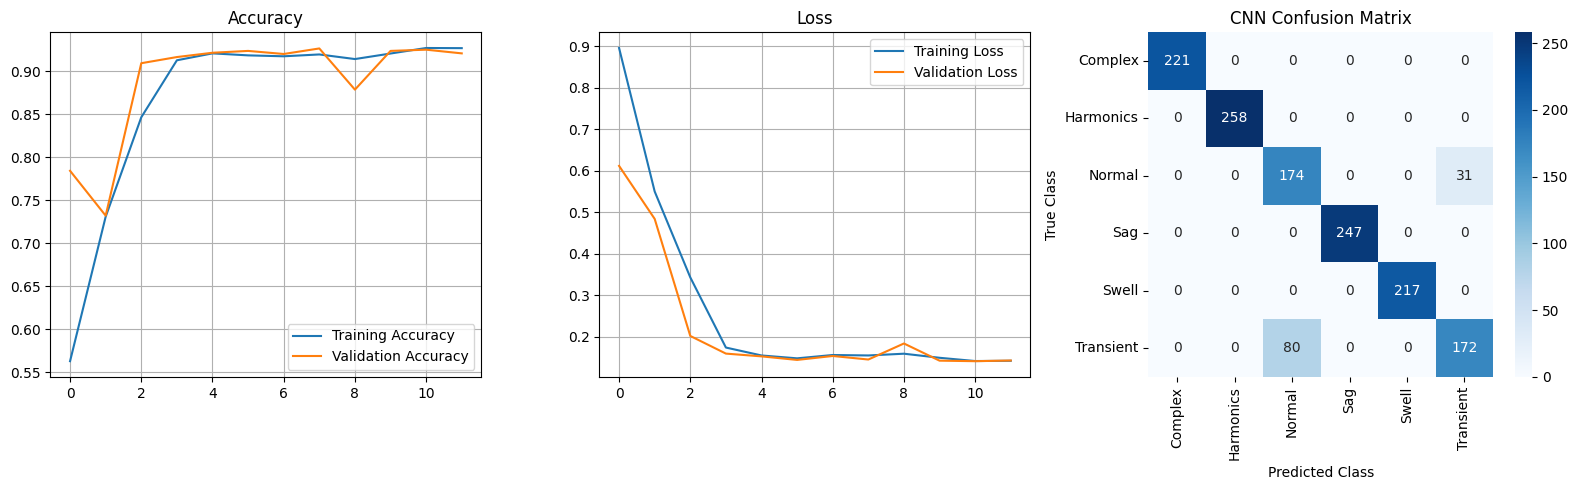


--- Proposed CNN Results ---
              precision    recall  f1-score   support

     Complex       1.00      1.00      1.00       221
   Harmonics       1.00      1.00      1.00       258
      Normal       0.69      0.85      0.76       205
         Sag       1.00      1.00      1.00       247
       Swell       1.00      1.00      1.00       217
   Transient       0.85      0.68      0.76       252

    accuracy                           0.92      1400
   macro avg       0.92      0.92      0.92      1400
weighted avg       0.93      0.92      0.92      1400



In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
#----------
# 1. Dataset Configuration
batch_size = 32
img_height = 128
img_width = 128
data_dir = "pq_complex_spectrograms"

print("Loading complex datasets...")
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size) # <-- shuffle=False has been removed!

class_names = train_ds.class_names
print(f"Target Classes: {class_names}")

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

#----------


# 2. Build the Advanced CNN Architecture
model = models.Sequential([
  layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),

  # Block 1: Extracts basic horizontal/vertical lines (Grid frequency vs Transients)
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),

  # Block 2: Extracts texture patterns (Harmonic bands)
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),

  # Block 3: Extracts complex overlapping features (Sag + Harmonics)
  layers.Conv2D(128, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),

  # Flatten and Classify
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dropout(0.3), # Increased dropout to 30% to prevent overfitting on complex noise
  layers.Dense(len(class_names)) # 6 output nodes now
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# 3. Train the Network
epochs = 12
print(f"\nStarting training for {epochs} epochs...")
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

# 4. Generate Predictions for the Confusion Matrix
print("\nGenerating predictions for Validation Set...")
# Extract the true labels from the validation dataset
y_true = np.concatenate([y for x, y in val_ds], axis=0)

# Get the model's predictions (logits) and find the highest probability class
predictions = model.predict(val_ds)
y_pred = np.argmax(predictions, axis=1)

# 5. Visualizations
# Plot A: Accuracy & Loss Curves
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(epochs)

plt.figure(figsize=(16, 5))
plt.subplot(1, 3, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Accuracy')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Loss')
plt.grid(True)

# Plot B: Confusion Matrix
plt.subplot(1, 3, 3)
conf_matrix = confusion_matrix(y_true, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('CNN Confusion Matrix')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')

plt.tight_layout()
plt.show()

# 6. Final Report
print("\n--- Proposed CNN Results ---")
print(classification_report(y_true, y_pred, target_names=class_names))